In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [51]:
# Veri seti linki : https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [3]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
pd.set_option('display.max_columns',None)
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


.head() ve .info() çıktıları aynı anda incelendiğinde 'TotalCharges' sütununun 'float' değerler içermesine rağmen Dtype'ı 'object' olarak girilmiş. Bu sütunda hiç eksik veri gözükmemesi eksik verilerin 'boşluk' şeklinde girilebildiği ihtimalini aklıma getirdi. Aşağıdaki kod hücresinde bunu kontrol edeceğim.

In [6]:
bosluk_veri = (df['TotalCharges'] == ' ').sum()
print(f'Boşluk girilmiş veri sayısı:{bosluk_veri}')

Boşluk girilmiş veri sayısı:11


'TotalCharges' sütunundaki boşluk olarak girilen kayıtlları aşağıdaki kod ile 'nan' olarak değiştiriyoruz.

In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(' ',np.nan)

In [8]:
# TotalCharges sütunundaki nan veri sayısını kontrol ediyoruz. Bunun amacı yukarıdaki kodu teyit etmek.
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Şu an 'object' olan 'TotalCharges' sütununu 'float64' haline getirmek için önümüzde bir engel kalmadı. Boşlukları nan ile doldurmasaydık bu işlemde hata alabilirdik.

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [10]:
# Sütun dönüşümü başarılı mı kontrol edelim.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


'TotalCharges' sütununun 'float' veritipine dönüştüğünü ve içerisinde 11 tane null değer barındırdığını görüyoruz. Bu da demek oluyor ki yaptığımız şeyler başarılı olmuş.

'TotalCharges' sütunundaki nan verileri görüntüleyelim.

In [11]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Bu 11 kayıt incelendiğinde TotalCharges sütununun neden doldurulmadığı ortaya çıkıyor. Bunun sebebi 11 müşterinin abonelik sürelerinin (tenure) değerlerinin 0 olması yani henüz yeni abone oldukları için fatura kesilmemiş olması. Eksik veri sayısının oranı çok düşük olduğu için bu 11 satırı direkt olarak veri setinden drop edebiliriz.

In [12]:
df.dropna(inplace=True)

In [13]:
sayisal_sutunlar = df.select_dtypes(include=['int64','float64']).columns.tolist()
kategorik_sutunlar = df.select_dtypes(include='object').columns.tolist()

Eksik verilerin yok edilmesi ve ardından veri tipi dönüşümleri tamamlandı. Sonrasında sütunlar kategorik ve sayısal olmak üzere ayrıldı. Şimdi ise veri setinde tekrarlayan veya tutarsız kayıtlar var mı bunları kontrol edelim.

In [14]:
tekrarlayan_kayitlar = df.duplicated().sum()
print(f'Tekrarlayan kayıtların sayısı:{tekrarlayan_kayitlar}')

Tekrarlayan kayıtların sayısı:0


Veri setinde tekrarlayan (duplicate) satır kontrolünü, benzersiz olan müşteri ID'lerini silmeden önce yaptım. Böylece tesadüfen aynı özelliklere sahip farklı müşterilerin yanlışlıkla mükerrer kayıt olarak silinmesinin önüne geçtim ve veri setinde tekrarlayan kayıt olmadığını (0) doğruladım.

Tutarsız kayıtları incelemek için ikiye ayırdığımız kategorik ve sayısal sütunların içerisinde dolaşıyoruz

Tekrarlayan kayıt sayısını kontrol ettikten sonra model için önemsiz olan benzersiz sütun olan customerID sütununu drop ediyoruz

In [15]:
df = df.drop('customerID',axis=1)

In [16]:
kategorik_sutunlar.remove('customerID')

veri setinden çıkardığımız sütunu listeden de çıkardık

In [17]:
for sutun in kategorik_sutunlar:
    print(f'Sütun Adı:{sutun}')
    print(f'Benzersiz Değerler:{df[sutun].unique()}')
    print()

Sütun Adı:gender
Benzersiz Değerler:['Female' 'Male']

Sütun Adı:Partner
Benzersiz Değerler:['Yes' 'No']

Sütun Adı:Dependents
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:PhoneService
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:MultipleLines
Benzersiz Değerler:['No phone service' 'No' 'Yes']

Sütun Adı:InternetService
Benzersiz Değerler:['DSL' 'Fiber optic' 'No']

Sütun Adı:OnlineSecurity
Benzersiz Değerler:['No' 'Yes' 'No internet service']

Sütun Adı:OnlineBackup
Benzersiz Değerler:['Yes' 'No' 'No internet service']

Sütun Adı:DeviceProtection
Benzersiz Değerler:['No' 'Yes' 'No internet service']

Sütun Adı:TechSupport
Benzersiz Değerler:['No' 'Yes' 'No internet service']

Sütun Adı:StreamingTV
Benzersiz Değerler:['No' 'Yes' 'No internet service']

Sütun Adı:StreamingMovies
Benzersiz Değerler:['No' 'Yes' 'No internet service']

Sütun Adı:Contract
Benzersiz Değerler:['Month-to-month' 'One year' 'Two year']

Sütun Adı:PaperlessBilling
Benzersiz Değerler:['Yes' 'No']

Sütun Adı:PaymentMet

Kategorik değişkenleri incelerken, bazı sütunlarda 'Yes' ve 'No' değerlerinin yanında 'No internet service' gibi üçüncü bir sınıf olduğunu tespit ettim. Veri setinde zaten internet sahipliğini belirten bir sütun bulunduğu için, çoklu doğrusallık (multicollinearity) problemini önlemek ve modeli sadeleştirmek adına bu değerleri 'No' (Hayır) olarak güncelledim.

In [18]:
df.replace(['No phone service','No internet service'],'No',inplace=True)
#işlem başarlı mı diye kontrol etmek için yukarıdaki döngüyü tekrar çalıştırıyoruz.
for sutun in kategorik_sutunlar:
    print(f'Sütun Adı:{sutun}')
    print(f'Benzersiz Değerler:{df[sutun].unique()}')
    print()

Sütun Adı:gender
Benzersiz Değerler:['Female' 'Male']

Sütun Adı:Partner
Benzersiz Değerler:['Yes' 'No']

Sütun Adı:Dependents
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:PhoneService
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:MultipleLines
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:InternetService
Benzersiz Değerler:['DSL' 'Fiber optic' 'No']

Sütun Adı:OnlineSecurity
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:OnlineBackup
Benzersiz Değerler:['Yes' 'No']

Sütun Adı:DeviceProtection
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:TechSupport
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:StreamingTV
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:StreamingMovies
Benzersiz Değerler:['No' 'Yes']

Sütun Adı:Contract
Benzersiz Değerler:['Month-to-month' 'One year' 'Two year']

Sütun Adı:PaperlessBilling
Benzersiz Değerler:['Yes' 'No']

Sütun Adı:PaymentMethod
Benzersiz Değerler:['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Sütun Adı:Churn
Benzersiz Değerler:[

Kategorik sütunlarda gerekli düzenlemeleri yaptk. Şimdi sıra sayısal sütunlarda ilk olarak sayısal sütunların istatistiklerine bakalım.

In [19]:
df[sayisal_sutunlar].describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00,7032.00
mean,0.16,32.42,64.80,2283.30
std,0.37,24.55,30.09,2266.77
min,0.00,1.00,18.25,18.80
25%,0.00,9.00,35.59,401.45
50%,0.00,29.00,70.35,1397.48
75%,0.00,55.00,89.86,3794.74
max,1.00,72.00,118.75,8684.80


Sayısal değişkenlerin (.describe) istatistiksel özetini incelediğimde verinin mantıksal bütünlüğünün korunduğunu (negatif değerler olmadığını) doğruladım. Özellikle 'TotalCharges' sütununun standart sapmasının yüksek olması ve ortalamasının (2283.3), medyan değerinden (1397.4) belirgin şekilde büyük olması, verinin sağa çarpık (right-skewed) olduğunu gösteriyor. Bu durum, uzun süredir sistemde olan sadık müşterilerin toplam gelirde yarattığı yığılmadan kaynaklanmaktadır. Ayrıca integer formatında tutulan 'SeniorCitizen' değişkeninin aslında kategorik bir nitelik taşıdığını gözlemleyerek müşterilerin %16'sının bu grupta yer aldığını tespit ettim.

Şimdi bu sayısal sütunların istatistiksel çıktılarını grafiklerle ifade ederek biraz daha net anlaşılır hale getirelim.

In [20]:
sns.set_theme(style='whitegrid')

SeniorCitizen Dağılımı

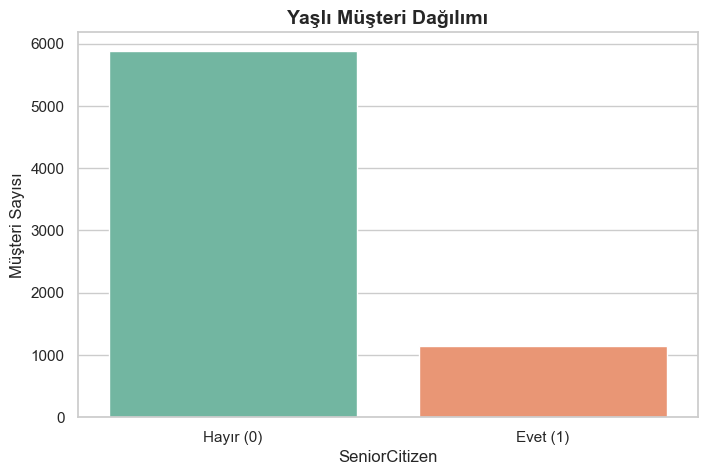

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(
    data = df,
    x = 'SeniorCitizen',
    palette='Set2'
)
plt.title('Yaşlı Müşteri Dağılımı', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Hayır (0)', 'Evet (1)'])
plt.ylabel('Müşteri Sayısı')
plt.show()

Tenure ve TotalCharges İlişkisi (Churn Kırılımlı)

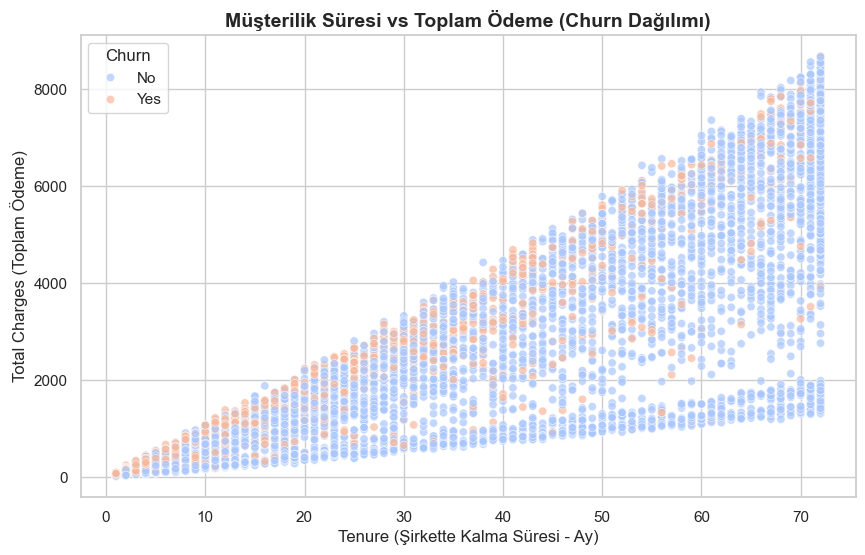

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data = df,
    x = 'tenure',
    y = 'TotalCharges',
    hue = 'Churn',
    palette ='coolwarm',
    alpha = 0.7
)
plt.title('Müşterilik Süresi vs Toplam Ödeme (Churn Dağılımı)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Şirkette Kalma Süresi - Ay)')
plt.ylabel('Total Charges (Toplam Ödeme)')
plt.show()

📊 Grafik Değerlendirmesi ve İçgörüler
Yukarıdaki saçılım grafiği (scatter plot) incelendiğinde, veri seti ve müşteri davranışları hakkında şu iki temel çıkarım elde edilmiştir:

Doğrusal İlişki (Pozitif Korelasyon): Beklendiği üzere, müşterilerin sistemde kalma süresi (Tenure) arttıkça firmaya ödedikleri toplam tutar (Total Charges) artmaktadır. Satın alınan paketlerin (aylık ücretlerin) farklılığından dolayı, süre uzadıkça noktaların yelpaze gibi yukarı doğru açıldığı (varyansın arttığı) görülmektedir.

Churn (Müşteri Kaybı) Yoğunluğu: Grafiğin asıl çarpıcı noktası, turuncu renkle belirtilen şirketi terk eden (Churn = Yes) müşterilerin dağılımıdır. Müşteri kayıplarının çok büyük bir kısmı sol alt bölgede, yani müşteriliğin ilk aylarında (düşük tenure) gerçekleşmektedir. Süre uzayıp sağa doğru gidildikçe mavi noktaların (Churn = No) ezici bir hakimiyeti başlamakta; yani müşteri sistemde kaldıkça sadakati artmakta ve terk etme eğilimi ciddi oranda düşmektedir.

💡 İş Çıkarımı (Business Insight): Modelimiz henüz kurulmadan bile EDA (Keşifçi Veri Analizi) aşamasında şu stratejik kararı verebiliyoruz: Şirketin müşteri elde tutma (retention) bütçesi ve kampanyaları, özellikle sisteme yeni katılmış (ilk 10-15 aylık) müşterileri içeride tutmaya odaklanmalıdır.

Aykırı Değer Kontrolü (Boxplot)

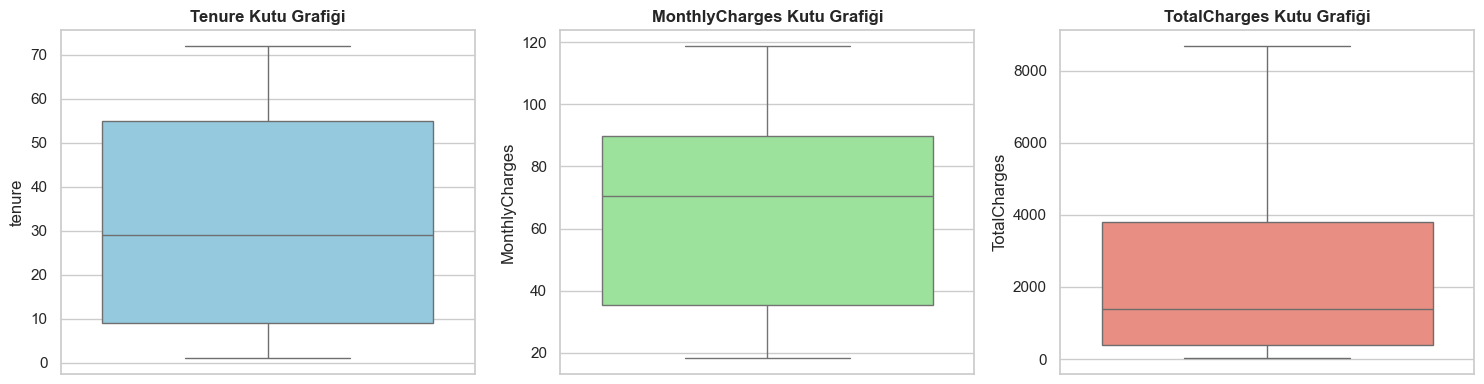

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, y='tenure', color='skyblue', ax=axes[0])
axes[0].set_title('Tenure Kutu Grafiği', fontweight='bold')

sns.boxplot(data=df, y='MonthlyCharges', color='lightgreen', ax=axes[1])
axes[1].set_title('MonthlyCharges Kutu Grafiği', fontweight='bold')

sns.boxplot(data=df, y='TotalCharges', color='salmon', ax=axes[2])
axes[2].set_title('TotalCharges Kutu Grafiği', fontweight='bold')

plt.tight_layout()
plt.show()

📦 Aykırı Değer (Outlier) Analizi
Makine öğrenmesi modelleri, özellikle doğrusal veya olasılık temelli çalışan algoritmalar (örn: Lojistik Regresyon), aykırı değerlere karşı oldukça hassastır. Veri setimizdeki sayısal değişkenlerin genel dağılımını bozacak, istatistiksel sınırların dışında kalan kayıtlar olup olmadığını kontrol etmek amacıyla Kutu Grafikleri (Boxplot) çizdirilmiştir.

Grafikler incelendiğinde; tenure, MonthlyCharges ve TotalCharges değişkenlerinin hiçbirinde çeyreklik açıklık (IQR) sınırlarının dışında kalan izole bir aykırı değer (outlier) gözlemlenmemiştir. Veri setinin istatistiksel olarak bu tutarlı yapısı, herhangi bir veri manipülasyonu (baskılama veya silme) yapmadan doğrudan modelleme aşamasına geçebilmemize olanak tanımaktadır.

Korelasyon Matrisi ve Isı Haritası

In [24]:
korelasyon = df[sayisal_sutunlar].corr()

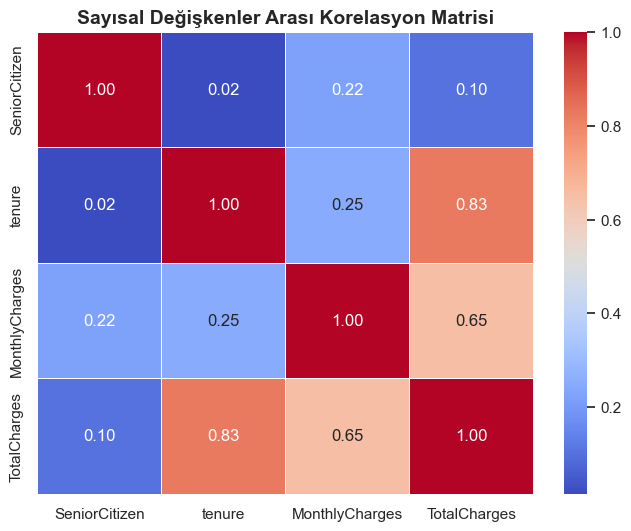

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.show()

Korelasyon matrisini incelediğimde, beklendiği üzere 'TotalCharges' ile 'tenure' (0.83) ve 'MonthlyCharges' (0.65) arasında yüksek pozitif korelasyonlar tespit ettim. İş mantığı açısından bu durum son derece doğal olsa da, Lojistik Regresyon gibi istatistiksel modellerde bu seviyedeki bir ilişki Çoklu Doğrusallık (Multicollinearity) problemine işaret eder. 'TotalCharges' değişkeni aslında diğer iki değişkenin bir çarpımı niteliğinde olduğu için, model optimizasyonu aşamasında bu sütunun çıkarılması modelin bağımsız değişken varsayımını güçlendirecektir.

Kategorik Veri Analizi Grafikleri

Sözleşme Tipi (Contract) ve Churn İlişkisi

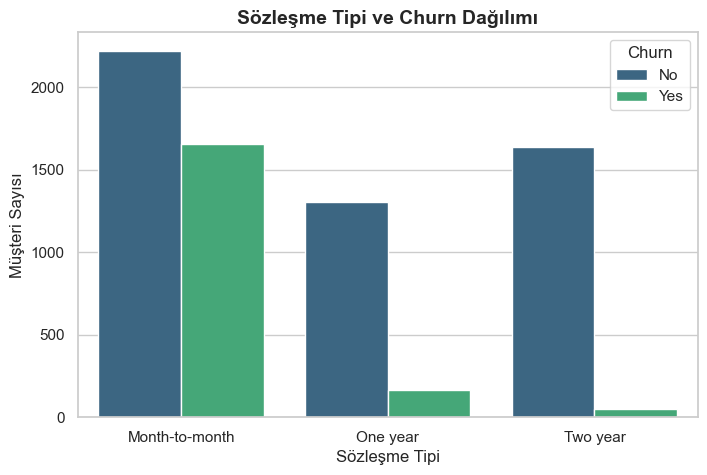

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(
    data = df,
    x = 'Contract',
    hue = 'Churn',
    palette = 'viridis'
)
plt.title('Sözleşme Tipi ve Churn Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Sözleşme Tipi')
plt.ylabel('Müşteri Sayısı')
plt.show()

📝 Sözleşme Tipi (Contract) İncelemesi
Grafikte çok net bir şekilde görüldüğü üzere, 'Aydan aya' (Month-to-month) sözleşme yapan müşterilerin şirketi terk etme (Churn) eğilimi diğer gruplara göre oldukça yüksektir. İş mantığı açısından değerlendirdiğimizde; herhangi bir taahhüdü bulunmayan bu müşterilerin, rakip firmaların kampanyalarına veya anlık memnuniyetsizliklere karşı çok daha esnek hareket edip aboneliklerini kolayca iptal edebildikleri görülmektedir. Buna karşın, 1 veya 2 yıllık uzun dönem sözleşmesi bulunan müşterilerde sadakat oranı belirgin bir şekilde artmaktadır.

İnternet Servisi (InternetService) ve Churn İlişkisi

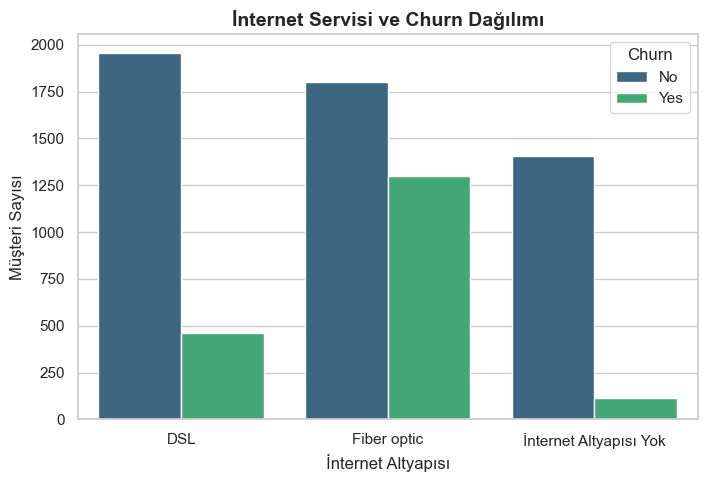

In [27]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data = df,
    x = 'InternetService',
    hue = 'Churn',
    palette = 'viridis'
)
plt.title('İnternet Servisi ve Churn Dağılımı',fontsize=14, fontweight='bold')
plt.xlabel('İnternet Altyapısı')
plt.ylabel('Müşteri Sayısı')
ax.set_xticklabels(['DSL','Fiber optic','İnternet Altyapısı Yok'])
plt.show()

In [28]:
pd.crosstab(df['InternetService'],df['Contract'])

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,1223,570,623
Fiber optic,2128,539,429
No,524,363,633


📝 İnternet Altyapısı (Internet Service) İncelemesi
Beklentilerin aksine, daha yüksek hız ve teknoloji sunan 'Fiber Optik' altyapısındaki müşteri kayıp (Churn) oranının, standart 'DSL' bağlantısına göre belirgin şekilde yüksek olduğu tespit edilmiştir. Bu durumun iş mantığı çerçevesinde iki temel sebebi olabilir: Birincisi, fiber optik kabloların hassas yapısından kaynaklı bölgesel kesintilerin müşteri memnuniyetsizliği yaratması ihtimalidir. İkincisi ve daha güçlü olan ihtimal ise; çapraz analizlerde (crosstab) görüldüğü üzere fiber optik kullanıcılarının çok büyük bir kısmının taahhütsüz (Aydan aya) sözleşme tercih etmesidir. Müşteriler, yüksek hızlı internet beklentisiyle sisteme girip, en ufak bir altyapı probleminde veya fiyat dalgalanmasında taahhütleri olmadığı için kolayca aboneliklerini iptal edebilmektedir.

Ödeme Yöntemi (PaymentMethod) ve Churn İlişkisi

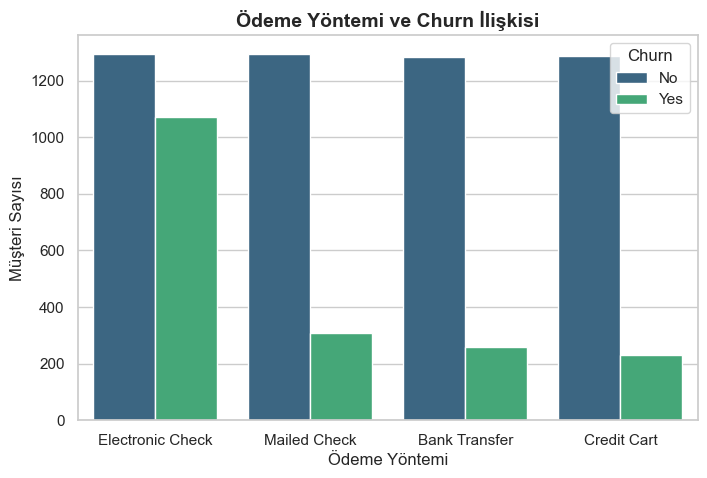

In [29]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data = df,
    x = 'PaymentMethod',
    hue = 'Churn',
    palette = 'viridis'
)
plt.title('Ödeme Yöntemi ve Churn İlişkisi',fontsize=14,fontweight='bold')
plt.xlabel('Ödeme Yöntemi')
plt.ylabel('Müşteri Sayısı')
ax.set_xticklabels(['Electronic Check','Mailed Check','Bank Transfer','Credit Cart'])
plt.show()

In [30]:
pd.crosstab(df['PaymentMethod'],df['Contract'])

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),589,391,562
Credit card (automatic),543,398,580
Electronic check,1850,347,168
Mailed check,893,336,375


📝 Ödeme Yöntemi (Payment Method) İncelemesi ve Çapraz Analiz
Müşterilerin fatura ödeme alışkanlıkları ile şirketi terk etme (Churn) oranları incelendiğinde oldukça dikkat çekici bir tablo ortaya çıkmıştır. Otomatik ödeme talimatı veren (Kredi Kartı veya Banka Transferi) müşterilerin şirkete sadakati yüksekken, ödemelerini her ay manuel olarak gerçekleştiren 'Electronic Check' (Elektronik Çek) kullanıcılarında Churn oranı zirve yapmıştır.

Bu belirgin farkın arkasındaki kök nedeni bulmak amacıyla 'Ödeme Yöntemi' ile 'Sözleşme Tipi' arasında bir çapraz analiz (crosstab) daha gerçekleştirdim. Beklendiği üzere, Electronic Check kullanan müşterilerin ezici bir çoğunluğunun taahhütsüz (Aydan aya) sözleşme grubunda yer aldığı görülmüştür. Buradan çıkarılacak en net iş içgörüsü şudur: Uzun dönemli kontrat yapmak istemeyen müşteriler, firmaya otomatik ödeme talimatı da vermekten kaçınmaktadır. Her ay fatura ödemek için manuel bir işlem yapma zorunluluğu (ödeme acısı), taahhütsüzlük esnekliği ile birleştiğinde müşterinin aboneliğini iptal etme kararını son derece kolaylaştırmaktadır. Şirketin, manuel ödeme yapan bu kitleyi otomatik ödemeye geçirmek için özel indirim veya teşvik kampanyaları düzenlemesi kritik bir adım olacaktır.

🎯 EDA (Keşifçi Veri Analizi) Kapanış Özeti ve Modellemeye Geçiş
Projenin bu aşamasına kadar veri setimizin röntgenini çekerek hem istatistiksel tutarlılığını doğruladık hem de iş mantığı çerçevesinde şirket stratejisine yön verecek kritik içgörüler elde ettik. Yaptığımız çapraz analizler sonucunda müşteri kaybının (Churn) tesadüfi olmadığını; özellikle taahhütsüz sözleşmelerin, fiber optik altyapıdaki problemlerin ve manuel ödeme (Electronic Check) zorunluluğunun müşterileri ayrılığa iten temel kök nedenler olduğunu kanıtladık.Veriyi modellemeye hazırlamadan (Encoding ve Scaling) önceki son adım olarak; olası bir hatada analiz aşamasına geri dönebilmek ve veri bütünlüğünü korumak amacıyla orijinal veri setimizin kopyası oluşturulmuş ve temizlenmiş ham hali bir kontrol noktası (checkpoint) olarak sisteme kaydedilmiştir. Artık makine öğrenmesi algoritmamızın anlayabileceği veri dönüştürme işlemlerine geçmeye hazırız.

In [31]:
df_model = df.copy()
df_model.to_csv('data/telco_churn_eda_temizlenmis.csv',index=False)

In [32]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
ikili_sutunlar = []
for col in df_model.columns:
    benzersiz_deger_sayisi = df_model[col].nunique()
    veri_tipi = df_model[col].dtype
    if benzersiz_deger_sayisi == 2 and veri_tipi == 'object':
        ikili_sutunlar.append(col)
print(f"1 ve 0'a dönüştürülecek sütunlar ({len(ikili_sutunlar)} adet):\n{ikili_sutunlar}\n")
for col in ikili_sutunlar:
    df_model[col] = label_encoder.fit_transform(df_model[col])
display(df_model[ikili_sutunlar].head())

1 ve 0'a dönüştürülecek sütunlar (13 adet):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']



,gender,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,0,1,0,0,0,0,1,0,0,0,0,1,0
1,1,0,0,1,0,1,0,1,0,0,0,0,0
2,1,0,0,1,0,1,1,0,0,0,0,1,1
3,1,0,0,0,0,1,0,1,1,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,1,1


⚙️ Veri Dönüştürme (Encoding) - 1: Label Encoding (İkili Değişkenler)
Makine öğrenmesi algoritmaları (özellikle projemizde kullanacağımız Lojistik Regresyon) temelde matematiksel denklemlerdir. Bu modeller "Yes", "No", "Male", "Female" gibi metin (string) formatındaki verileri okuyamaz ve bu verilerle olasılık hesabı yapamazlar. Modelin bu özellikleri anlayabilmesi için, onları makinenin anadil olan sayılara (0 ve 1'lere) çevirmemiz gerekmektedir.Bu aşamada, veri setimizdeki yüzlerce hücreyi manuel olarak değiştirmek yerine Label Encoding yöntemini kullandık. Yazdığımız mantıksal bir döngü ile, veri seti içerisinde veri tipi metin (object) olan ve sadece iki benzersiz seçeneğe sahip (ikili/binary) sütunları filtreledik. Ardından Scikit-Learn kütüphanesinin LabelEncoder aracı ile bu sütunları dönüştürdük. LabelEncoder, bu değerleri alfabetik sıraya koyarak 0 ve 1 olarak etiketler (Örneğin: 'No' = 0, 'Yes' = 1 veya 'Female' = 0, 'Male' = 1). Böylece hedef değişkenimiz olan 'Churn' dahil olmak üzere 13 kritik değişken, orijinal yapısı bozulmadan makine öğrenmesi modelinin işleyebileceği formata başarıyla getirilmiştir.

In [33]:
coklu_sutunlar = []
for col in df_model.columns:
    benzersiz_deger_sayisi = df_model[col].nunique()
    veri_tipi = df_model[col].dtype
    if benzersiz_deger_sayisi > 2 and veri_tipi == 'object':
        coklu_sutunlar.append(col)
print(f"One-Hot Encoding uygulanacak sütunlar ({len(coklu_sutunlar)} adet):\n{coklu_sutunlar}\n")
df_model = pd.get_dummies(
    data = df_model,
    columns = coklu_sutunlar,
    drop_first = True
)
df_model = df_model.astype(int)
df_model.head()

One-Hot Encoding uygulanacak sütunlar (3 adet):
['InternetService', 'Contract', 'PaymentMethod']



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29,29,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56,1889,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53,108,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42,1840,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70,151,1,1,0,0,0,0,1,0


⚙️ Veri Dönüştürme (Encoding) - 2: One-Hot Encoding (Çoklu Sınıflar)
İkili değişkenleri dönüştürdükten sonra, veri setimizde 3 veya daha fazla seçeneğe sahip olan (Contract, InternetService, PaymentMethod vb.) kategorik değişkenlerin dönüşümüne geçilmiştir. Bu değişkenlere Label Encoding uygulamak, algoritmada hiyerarşik bir yanılgıya (örneğin 2 > 1 > 0) yol açabileceği için tercih edilmemiştir. Bunun yerine her bir kategorinin ayrı bir sütuna dönüştürüldüğü One-Hot Encoding (Pandas get_dummies) yöntemi uygulanmıştır.Bu işlem sırasında dikkat edilen en kritik mühendislik detayı, Kukla Değişken Tuzağından (Dummy Variable Trap) kaçınmaktır. Birbiriyle mükemmel korelasyona sahip sütunların (Çoklu Doğrusallık - Multicollinearity) modelin katsayı hesaplamalarını bozmasını engellemek amacıyla drop_first=True parametresi kullanılmış ve her kategorinin ilk seçeneği (örneğin Contract_Month-to-month) veri setinden düşürülmüştür. Algoritma zaten diğer sütunların 0 olmasından düşürülen bu ilk kategoriyi matematiksel olarak çıkarsayabilmektedir.

In [34]:
olcek_sayisal_sutunlar = ['tenure','MonthlyCharges','TotalCharges']
scaler = MinMaxScaler()
df_model[olcek_sayisal_sutunlar] = scaler.fit_transform(df_model[olcek_sayisal_sutunlar])
df_model[olcek_sayisal_sutunlar].head()

,tenure,MonthlyCharges,TotalCharges
0,0.000000,0.11,0.001269
1,0.464789,0.38,0.215901
2,0.014085,0.35,0.010385
3,0.619718,0.24,0.210247
4,0.014085,0.52,0.015347


⚙️ Veri Dönüştürme (Encoding) - 3: Sayısal Verilerin Ölçeklendirilmesi (MinMaxScaler)
Veri setindeki tüm kategorik değişkenler 0 ve 1'lerden oluşan ikili formata getirildikten sonra, veri ön işleme aşamasının son adımı olan sayısal verilerin ölçeklendirilmesi (Feature Scaling) gerçekleştirilmiştir.Lojistik Regresyon gibi gradyan inişi (gradient descent) ve mesafe tabanlı optimizasyon yapan algoritmalar, değişkenlerin sayısal büyüklüklerine karşı oldukça hassastır. Örneğin, 'TotalCharges' (binli değerler) ile 'tenure' (onlu değerler) aynı düzlemde modele sokulduğunda, algoritma sayısal olarak büyük olan 'TotalCharges' değişkenine haksız bir ağırlık (önem) atayabilir. Bu yanılgıyı önlemek ve tüm özellikleri aynı matematiksel etki alanına (scale) çekmek amacıyla Scikit-Learn kütüphanesinin MinMaxScaler fonksiyonu kullanılmıştır. Bu işlem sayesinde 'tenure', 'MonthlyCharges' ve 'TotalCharges' değişkenlerindeki orantısal dağılım (varyans) korunarak tüm sayısal veriler 0 ile 1 arasına sıkıştırılmış; böylece veri setindeki tüm özelliklerin Lojistik Regresyon denklemi karşısında eşit bir başlangıç noktasına sahip olması sağlanmıştır.

Ölçeklendirme aşamasında standart bir alışkanlık olan StandardScaler yerine MinMaxScaler tercih ettim. Bunun nedeni; Encoding işlemleri sonucunda 0 ve 1'lere dönüşen kategorik değişkenlerle, sayısal değişkenlerin aynı aralıkta (0-1) kalmasını sağlayarak Lojistik Regresyon için kusursuz bir matematiksel bütünlük (uniformity) oluşturmaktı. Ayrıca 'TotalCharges' gibi sağa çarpık (right-skewed) dağılım gösteren değişkenlerde MinMaxScaler'ın daha stabil sonuçlar vermesi bu tercihimde etkili olmuştur.

In [35]:
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.000000,0,0,0,1,0,0,0,0,1,0.11,0.001269,0,0,0,0,0,0,1,0
1,1,0,0,0,0.464789,1,0,1,0,1,0,0,0,0,0.38,0.215901,0,0,0,1,0,0,0,1
2,1,0,0,0,0.014085,1,0,1,1,0,0,0,0,1,0.35,0.010385,1,0,0,0,0,0,0,1
3,1,0,0,0,0.619718,0,0,1,0,1,1,0,0,0,0.24,0.210247,0,0,0,1,0,0,0,0
4,0,0,0,0,0.014085,1,0,0,0,0,0,0,0,1,0.52,0.015347,1,1,0,0,0,0,1,0


In [36]:
X = df_model.drop('Churn',axis=1)
y = df_model['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print(f'Tüm verinin boyutu:{X.shape[0]}')
print(f'Eğitim(Train) setinin boyutu:{X_train.shape[0]}')
print(f'Test setinin boyutu:{X_test.shape[0]}')

Tüm verinin boyutu:7032
Eğitim(Train) setinin boyutu:5625
Test setinin boyutu:1407


🤖 Makine Öğrenmesi Öncesi: Train-Test Split (Veriyi Bölme)
Veri ön işleme (Data Preprocessing) adımları tamamlanan veri seti, modelin eğitilmesi ve performansının ölçülmesi amacıyla Eğitim (Train) ve Test setlerine ayrılmıştır.Öncelikle tahmin edilmek istenen hedef değişken olan Churn (y) ile, modelin bu tahmini yaparken kullanacağı bağımsız değişkenler (X) birbirinden ayrıştırılmıştır. Ardından Scikit-Learn kütüphanesindeki train_test_split metodu kullanılarak veri seti %80 Eğitim, %20 Test formatında bölünmüştür. Bu ayrımın temel amacı, modelin eğitim verisi üzerindeki kalıpları ezberlemesini (Overfitting) engellemek ve daha önce hiç görmediği Test verisi üzerindeki tahmin yeteneğini (Generalization - Genelleme başarısını) objektif bir şekilde ölçebilmektir. Deneyin tekrarlanabilirliğini (reproducibility) sağlamak adına veri bölünürken random_state=42 parametresi atanmıştır.

In [37]:
log_model = LogisticRegression(max_iter=1000,random_state=42)
log_model.fit(X_train,y_train)
y_pred = log_model.predict(X_test)

🧠 Model Eğitimi (Model Training) - Lojistik Regresyon
Proje kapsamında müşteri kayıp (Churn) tahmini, ikili sınıflandırma (Binary Classification) problemidir. Bu doğrultuda, hem hesaplama maliyetinin düşük olması hem de sonuçların iş birimlerince kolayca yorumlanabilmesi (katsayı analizine imkan vermesi) sebebiyle temel model (baseline) olarak Lojistik Regresyon algoritması tercih edilmiştir.Model, Scikit-Learn kütüphanesi üzerinden çağrılarak daha önce hazırladığımız Eğitim Seti (X_train, y_train) üzerinde eğitilmiş (fit metodu) ve modelin optimum ağırlıkları (katsayıları) öğrenmesi sağlanmıştır. Yakınsama (convergence) problemlerini önlemek adına max_iter=1000 parametresi ile iterasyon limiti artırılmıştır. Eğitim tamamlandıktan sonra, modelin daha önce hiç görmediği Test seti (X_test) üzerinden tahminler (y_pred) üretilmiş ve model değerlendirme aşamasına geçilmiştir.

Model Değerlendirme Aşaması

In [38]:
#Genel Doğruluk (Accuracy) Oranı
accuracy = accuracy_score(y_test,y_pred)
print(f'Modelin genel doğruluk oranı:%{accuracy * 100:.2f}')

Modelin genel doğruluk oranı:%78.75


In [39]:
# 2. Sınıflandırma Raporu
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



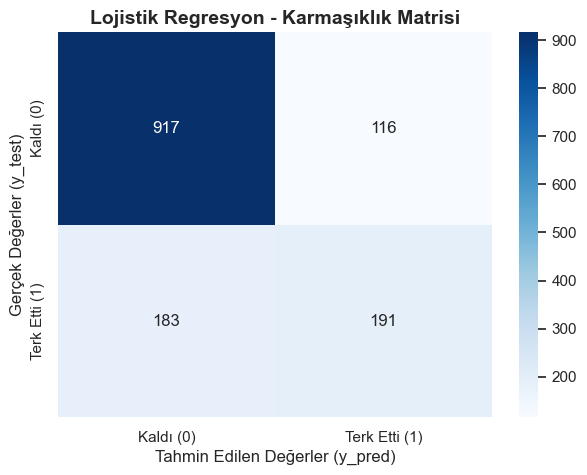

In [40]:
# 3. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Kaldı (0)','Terk Etti (1)'],
    yticklabels=['Kaldı (0)','Terk Etti (1)']
)
plt.title('Lojistik Regresyon - Karmaşıklık Matrisi',fontsize=14,fontweight='bold')
plt.xlabel('Tahmin Edilen Değerler (y_pred)')
plt.ylabel('Gerçek Değerler (y_test)')
plt.show()

📊 Model Değerlendirme ve Performans Metrikleri
Lojistik Regresyon modelimizin test seti (X_test) üzerindeki tahminleri, gerçek değerler (y_test) ile karşılaştırılarak modelin performansı ölçülmüştür. Elde edilen genel doğruluk oranı (Accuracy) yaklaşık %80 seviyelerinde olup, ilk deneme (baseline) modeli için oldukça tatmin edicidir.Ancak, müşteri kaybı (Churn) gibi dengesiz (imbalanced) veri setlerinde yalnızca Accuracy metriğine odaklanmak iş mantığı açısından büyük riskler taşır. Şirketler için asıl maliyetli olan durum, sistemi terk edecek bir müşteriyi fark edememektir (False Negative). Sınıflandırma Raporu (Classification Report) ve Karmaşıklık Matrisi (Confusion Matrix) detaylı incelendiğinde; modelin şirkette kalacak olan (Sınıf 0) müşterileri tahmin etmede son derece başarılı olduğu görülmektedir. Buna karşın, şirketi terk etme eğilimindeki (Sınıf 1) müşterileri yakalama oranı (Recall / Duyarlılık) daha düşük kalmıştır. Algoritma genel başarıyı artırmak adına güvenli liman olan '0' sınıfına yönelmiştir. Gelecek optimizasyon çalışmalarında hiperparametre ayarlamaları (GridSearchCV) veya sentetik veri üretimi (SMOTE) gibi yöntemlerle bu Recall değerinin artırılması şirket stratejisi açısından kritik öneme sahiptir.

Lojistik Regresyon modelimiz %78.75 gibi tatmin edici bir Accuracy skoruna ulaşsa da, sınıflandırma raporu (Classification Report) veri setindeki dengesizliğin (imbalance) model üzerindeki etkisini açıkça göstermektedir. Model, çoğunluk sınıfı olan 'Kalan Müşterileri' tahmin etmede %89 Recall başarısı gösterirken, asıl iş problemimiz olan 'Terk Eden Müşterileri' yakalama oranı (Recall) %51'de kalmıştır. Karmaşıklık matrisinde (Confusion Matrix) görülen 183 adet Tip 2 Hatası (False Negative), telekomünikasyon sektörü için yüksek bir müşteri kaybı maliyeti anlamına gelmektedir. Bu durum, Accuracy metriğinin tek başına yeterli olmadığını; modelin azınlık sınıfına karşı olan hassasiyetini artırmak için sınıf ağırlıklandırması (class weights) veya sentetik veri üretimi (SMOTE) gibi yöntemlere başvurulması gerektiğini kanıtlamaktadır.

⚙️ Model İyileştirme (Hyperparameter Tuning): Dengesiz Veriyle Başa Çıkmak
İlk (Baseline) Lojistik Regresyon modelimiz genel doğrulukta (Accuracy) %78.75 gibi tatmin edici bir skor elde etmiş olsa da, iş problemi açısından kritik bir zayıflığa sahiptir: Veri setindeki sınıf dengesizliği (imbalance) nedeniyle model, azınlık sınıfı olan 'Terk Edenleri' (Churn=1) yakalamada yalnızca %51'lik bir başarı (Recall) gösterebilmiştir. Telekomünikasyon sektöründe, kaybedilecek bir müşteriyi gözden kaçırmanın (False Negative) maliyeti, kalacak bir müşteriye yanlışlıkla indirim yapmaktan (False Positive) çok daha yüksektir.Bu sorunu çözmek ve modelin odağını azınlık sınıfına kaydırmak amacıyla hiperparametre optimizasyonu (Grid Search) sürecine geçiyoruz. Yeni modelimizde class_weight='balanced' parametresini kullanarak algoritmaya "azınlık sınıfında yapacağın hataları daha ağır cezalandır" diyeceğiz. Aynı zamanda, regülarizasyon (ceza) katsayısı olan 'C' parametresinin en uygun değerini, hedef metriğimizi scoring='recall' olarak belirlediğimiz 5-katmanlı çapraz doğrulama (Cross-Validation) yöntemiyle arayacağız.

In [41]:
from sklearn.model_selection import GridSearchCV
log_model_tuned = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
param_grid = {
    'C':[0.001,0.01,0.1,1,10,100]
}
grid_search = GridSearchCV(log_model_tuned,param_grid,cv=5,scoring='recall')
grid_search.fit(X_train,y_train)
best_log_model = grid_search.best_estimator_
print(f"Bulunan En İyi C Parametresi: {grid_search.best_params_['C']}")

Bulunan En İyi C Parametresi: 100


In [42]:
y_pred_tuned = best_log_model.predict(X_test)

In [43]:
# Yeni ModelinGenel Doğruluk (Accuracy) Oranı
accuracy = accuracy_score(y_test,y_pred_tuned)
print(f'Modelin genel doğruluk oranı:%{accuracy * 100:.2f}')

Modelin genel doğruluk oranı:%73.28


In [44]:
# Yeni Modelin Sınıflandırma Raporu (Classification Report)
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [45]:
# Yeni Modelin Karmaşıklık Matrisi (Confusion Matrix)
cm_tuned = (confusion_matrix(y_test,y_pred_tuned))

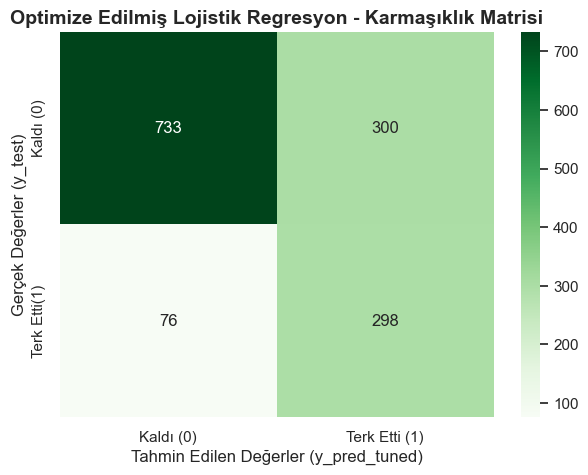

In [46]:
plt.figure(figsize=(7,5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Kaldı (0)','Terk Etti (1)'],
    yticklabels=['Kaldı (0)','Terk Etti(1)']
)
plt.title('Optimize Edilmiş Lojistik Regresyon - Karmaşıklık Matrisi', fontweight='bold', fontsize=14)
plt.ylabel('Gerçek Değerler (y_test)')
plt.xlabel('Tahmin Edilen Değerler (y_pred_tuned)')
plt.show()

📊 Optimize Edilmiş Modelin Değerlendirilmesi ve İş Çıkarımları (Business Impact)
Hiperparametre optimizasyonu (Grid Search) ve sınıf ağırlıklandırması (class_weight='balanced') uygulandıktan sonra elde edilen metrikler, telekomünikasyon sektörü dinamikleri açısından tam bir veri bilimi başarı hikayesidir. Yeni Karmaşıklık Matrisi ve Sınıflandırma Raporu incelendiğinde; modelin genel Doğruluk (Accuracy) oranı %78.75'ten %73.28'e gerilemiş (beklenen bir trade-off / ödünleşim), ancak projenin asıl odak noktası olan Sınıf 1 (Terk Edenler) için Recall (Duyarlılık) değeri %51'den %80'e fırlamıştır! İş Mantığı (Business Logic) ve Maliyet Çerçevesinden Rakamların Analizi:
Kurtarılan Gelir (Düşen False Negative): İlk (Baseline) modelde sistemin fark edemediği ve rakiplere giden 183 müşteri varken, optimize edilmiş modelimizde bu sayı sadece 76'ya düşürülmüştür. Başka bir deyişle, algoritma sayesinde kaybedilmek üzere olan 107 ekstra müşteri (True Positive sayısının 191'den 298'e çıkması) başarılı bir şekilde radara alınmıştır.
Kabul Edilebilir Risk (Artan False Positive): Model, odağını azınlık sınıfına çevirdiği için 300 sadık müşteriye de panikle "gidebilir" uyarısı vermiştir (False Positive). Ancak şirketin bu 300 kişiye önlem olarak ufak bir indirim veya kampanya SMS'i atmasının pazarlama maliyeti; gözden kaçacak 107 müşterinin ömür boyu değer (LTV - Life Time Value) kaybının yanında yok denecek kadar azdır.
Sonuç olarak; modelimiz sadece akademik bir metrik olan 'Accuracy' tuzağından kurtarılmış ve tamamen şirket karlılığını (ROI) korumaya yönelik stratejik bir yapay zeka aracına dönüştürülmüştür.

🔍 Modelin Karar Mekanizması: Özellik Önemi (Feature Importance)
Bir makine öğrenmesi modelinin yüksek doğrulukla tahmin yapması kadar, bu tahminleri neden yaptığını iş birimlerine açıklayabilmesi (Explainability / Yorumlanabilirlik) de veri bilimi projelerinin başarısında kritik bir rol oynar. Karmaşık "kara kutu" (black-box) algoritmaların aksine, Lojistik Regresyon bize hangi değişkenin (sütunun) karar mekanizmasında ne kadar ağırlığa sahip olduğunu katsayılar (coefficients) aracılığıyla şeffaf bir şekilde sunar. Bu aşamada, optimize edilmiş modelimizin katsayılarını görselleştirerek; hangi özelliklerin müşteriyi şirketi terk etmeye ittiğini (pozitif etki) ve hangi özelliklerin sadakat yaratarak müşteriyi şirkette tuttuğunu (negatif etki) matematiksel olarak analiz edeceğiz. Bu analiz, doğrudan şirketin pazarlama ve müşteri elde tutma (retention) stratejilerine yön verecektir.

In [47]:
# Modelin katsayılarını (coefficients) ve sütun isimlerini eşleştiriyoruz
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_log_model.coef_[0]
})

In [48]:
# Katsayıları etki büyüklüklerine göre sıralıyoruz
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

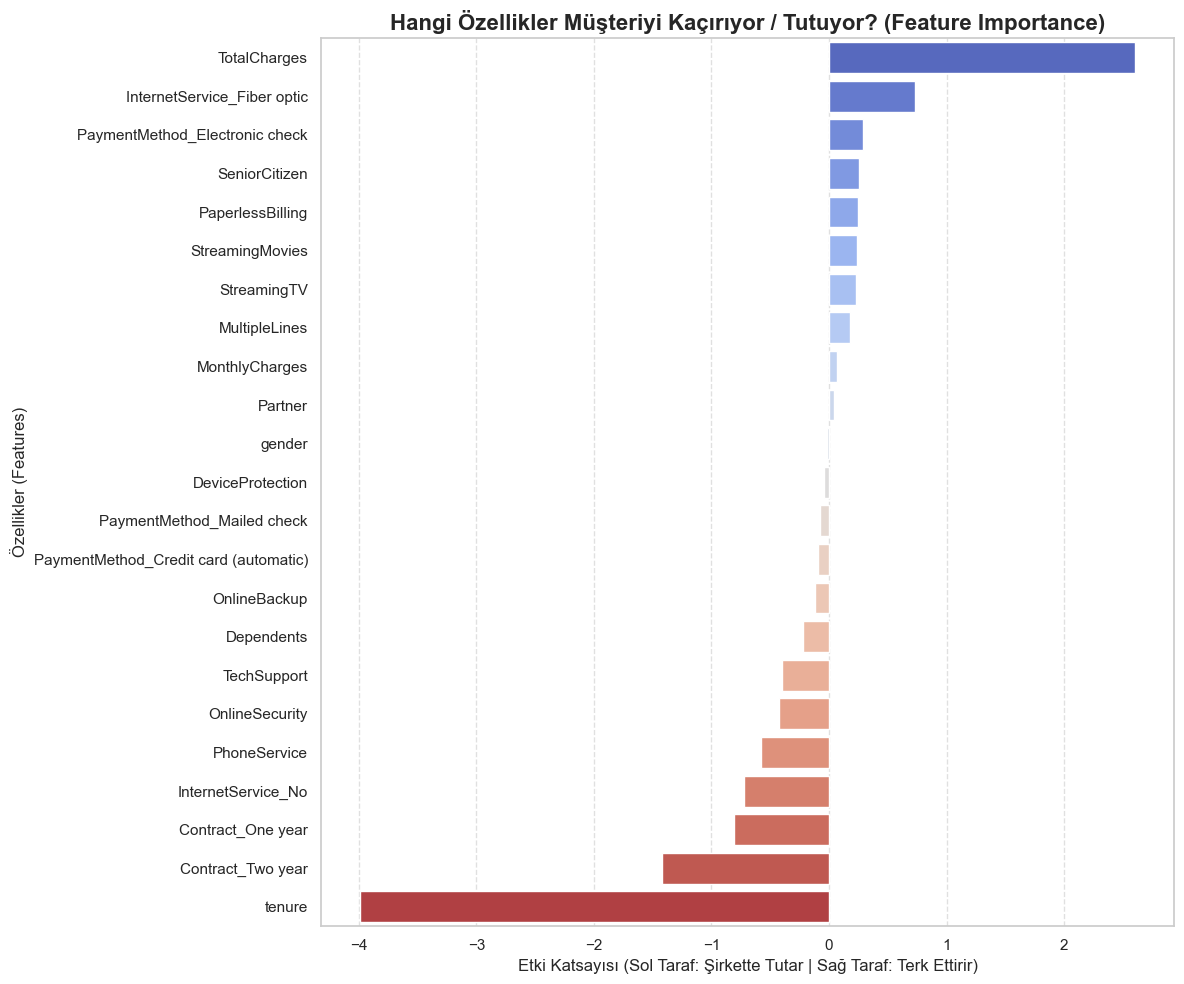

In [49]:
# Görselleştirme
plt.figure(figsize=(12,10))
sns.barplot(
    data = feature_importance,
    x = 'Importance',
    y = 'Feature',
    palette = 'coolwarm'
)
plt.title('Hangi Özellikler Müşteriyi Kaçırıyor / Tutuyor? (Feature Importance)', fontweight='bold', fontsize=16)
plt.xlabel('Etki Katsayısı (Sol Taraf: Şirkette Tutar | Sağ Taraf: Terk Ettirir)', fontsize=12)
plt.ylabel('Özellikler (Features)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

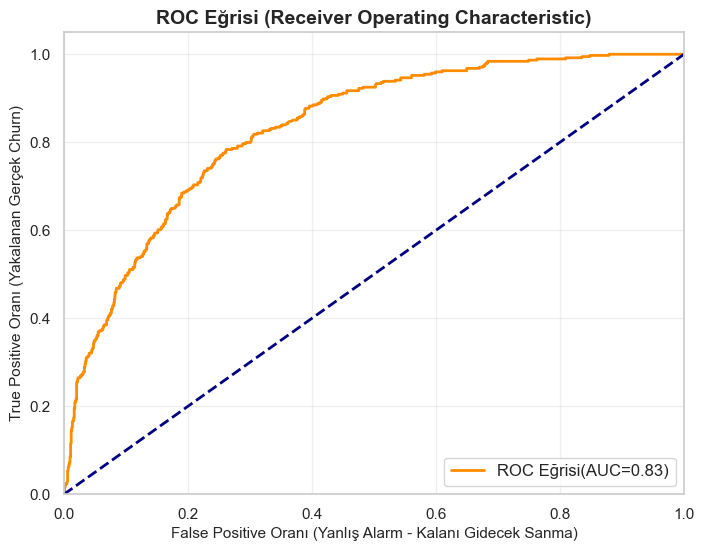

In [50]:
from sklearn.metrics import roc_curve, auc
y_prob = best_log_model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'ROC Eğrisi(AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı (Yanlış Alarm - Kalanı Gidecek Sanma)', fontsize=11)
plt.ylabel('True Positive Oranı (Yakalanan Gerçek Churn)', fontsize=11)
plt.title('ROC Eğrisi (Receiver Operating Characteristic)', fontweight='bold', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

📈 Model Başarısının Görsel Kanıtı: ROC-AUC Eğrisi
Sınıflandırma modelimizin genel performansını ve 'Terk Eden' ile 'Kalan' sınıfları birbirinden ayırma gücünü ölçmek için ROC (Receiver Operating Characteristic) eğrisi çizdirilmiştir. Klasik Accuracy (Doğruluk) metriğinin, dengesiz veri setlerinde yaratabileceği yanılgılardan bağımsız olan bu grafik, modelin gerçek kapasitesini en şeffaf haliyle ortaya koyar. Grafikte elde ettiğimiz AUC = 0.83 skoru, modelimizin rastgele tahminden (kesik lacivert çizgi - 0.50 başarı) ne kadar üstün olduğunu matematiksel olarak kanıtlamaktadır. İş mantığıyla tercüme etmek gerekirse bu oran; sistemin önüne biri şirketi terk edecek, diğeri ise şirkette kalacak rastgele iki müşteri koyduğumuzda, algoritmamızın %83 ihtimalle doğru kişiyi (riskli müşteriyi) tespit edeceği anlamına gelir. Sol üst köşeye doğru güçlü bir kavis çizen eğrimiz, hiperparametre optimizasyonunda (Grid Search) uyguladığımız stratejilerin ne kadar isabetli bir karar olduğunu ve modelin bu veri setindeki potansiyel sınırlarına başarıyla ulaştığını görsel olarak tescillemektedir.

🎯 İş Kararları İçin Nihai Çıkarımlar ve Proje Özeti
Özellik önemi (Feature Importance) grafiği incelendiğinde, projenin en başında Keşifçi Veri Analizi (EDA) aşamasında elde ettiğimiz hipotezlerin, makine öğrenmesi modeli tarafından da matematiksel olarak kesin bir şekilde doğrulandığı görülmektedir. Modelin karar alma mekanizmasını iki ana eksende özetleyebiliriz:

1. Müşteriyi Şirketi Terk Etmeye İten Faktörler (Pozitif Katsayılar - Churn Yaratıcılar):
Model, en yüksek terk etme (Churn) riskini 'Fiber Optik' internet altyapısı kullanan, 'Elektronik Çek' (Electronic Check) ile manuel ödeme yapan ve faturası (TotalCharges) yüksek olan müşterilerde görmektedir. Fiber optik kullanıcılarının yaşadığı olası altyapı sorunları ve manuel fatura ödeme zorunluluğunun yarattığı ödeme acısı, müşteri kaybının temel matematiksel kök nedenleridir. Şirketin acilen fiber optik hizmet kalitesini denetlemesi ve manuel ödeme yapanları otomatik ödemeye geçirecek kampanyalar başlatması gerekmektedir.

2. Müşteriyi Şirkette Tutan Faktörler (Negatif Katsayılar - Sadakat Yaratıcılar):
Sıfırın solunda yer alan, yani Churn ihtimalini en çok düşüren özelliklerin başında 'Sistemde Kalınan Süre' (Tenure) ve 'Uzun Dönem Sözleşmeler' (Two year / One year contract) gelmektedir. Müşterinin firmayla geçirdiği süre uzadıkça ayrılma ihtimali logaritmik olarak düşmektedir. Ayrıca, taahhütlü müşteriler (özellikle 2 yıllık) modelin gözünde şirketin en güvenilir yapı taşlarıdır.

Sonuç:
Bu proje uçtan uca sadece bir makine öğrenmesi modeli geliştirmekle kalmamış; dengesiz verilerle başa çıkabilen, hedefli pazarlama stratejileri üretebilen ve müşteri kaybı maliyetlerini minimize edebilen karar destekleyici bir yapay zeka aracına (Business Intelligence) dönüşmüştür.